In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

pd.set_option("display.max_columns", None)
print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.21.0


In [4]:
DATA_PATH = r"D:\CSIR\Chronic_Kidney_Disease\CKD_Dataset.csv"

SEED = 42
INCLUDE_GFR = True         # ckd_stage is defined from GFR. False -> accuracy stays near chance.
INCLUDE_LIFESTYLE = False  # lifestyle columns have ~0 correlation with stage; adding them only adds noise

# Columns that must NOT be used as inputs: ckd_pred == (stage 0) exactly; cluster origin unknown
LEAKY_COLS = ["ckd_pred", "cluster"]

LAB_FEATURES = [
    "gfr", "serum_creatinine", "bun", "serum_calcium", "ana", "c3_c4",
    "hematuria", "oxalate_levels", "urine_ph", "blood_pressure",
]
LIFESTYLE_FEATURES = [
    "physical_activity", "diet", "water_intake", "smoking", "alcohol",
    "painkiller_usage", "family_history", "weight_changes", "stress_level", "months",
]

STAGE_NAMES = ["No CKD", "Stage 1", "Stage 2", "Stage 3", "Stage 4", "Stage 5"]

random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

In [5]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (4000, 23)


,serum_creatinine,gfr,bun,serum_calcium,ana,c3_c4,hematuria,oxalate_levels,urine_ph,blood_pressure,physical_activity,diet,water_intake,smoking,alcohol,painkiller_usage,family_history,weight_changes,stress_level,months,cluster,ckd_pred,ckd_stage
0,0.683683,32.946784,7.553739,10.039896,0,138.204989,0,2.878164,7.864308,115.224217,weekly,high protein,2.314979,yes,daily,no,yes,stable,low,10,5,CKD,3
1,3.809044,32.685035,141.347494,8.330543,1,24.282343,1,4.767639,4.920015,130.143900,weekly,high protein,2.250649,yes,daily,no,yes,loss,moderate,1,2,CKD,3
2,1.143827,2.079805,15.979104,9.419229,0,163.970666,0,1.818613,6.188115,98.026072,weekly,low salt,2.542343,no,daily,no,no,stable,moderate,4,6,CKD,5
3,4.804657,109.871407,53.307333,7.556631,1,71.056846,1,4.051686,5.278607,142.166650,rarely,low salt,2.640812,no,never,yes,yes,stable,high,9,2,CKD,1
4,4.920235,42.214590,134.182157,7.289379,1,23.384639,1,3.240920,4.862923,151.962572,weekly,balanced,3.148921,no,occasionally,yes,no,gain,high,7,2,CKD,3


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Number of rows: 4000
Number of columns: 23

Column names:
['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure', 'physical_activity', 'diet', 'water_intake', 'smoking', 'alcohol', 'painkiller_usage', 'family_history', 'weight_changes', 'stress_level', 'months', 'cluster', 'ckd_pred', 'ckd_stage']

Data types:
serum_creatinine     float64
gfr                  float64
bun                  float64
serum_calcium        float64
ana                    int64
c3_c4                float64
hematuria              int64
oxalate_levels       float64
urine_ph             float64
blood_pressure       float64
physical_activity        str
diet                     str
water_intake         float64
smoking                  str
alcohol                  str
painkiller_usage         str
family_history           str
weight_changes           str
stress_level             str
months                 int64
cluster                int64
ckd_pr

In [7]:
print("CKD Stage Distribution:")
print(df["ckd_stage"].value_counts().sort_index())

print("\nCKD Stage Percentage:")
print(df["ckd_stage"].value_counts(normalize=True).sort_index().mul(100).round(2))

CKD Stage Distribution:
ckd_stage
0     125
1     545
2    1004
3     866
4     794
5     666
Name: count, dtype: int64

CKD Stage Percentage:
ckd_stage
0     3.12
1    13.63
2    25.10
3    21.65
4    19.85
5    16.65
Name: proportion, dtype: float64


In [8]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
serum_creatinine     0
gfr                  0
bun                  0
serum_calcium        0
ana                  0
c3_c4                0
hematuria            0
oxalate_levels       0
urine_ph             0
blood_pressure       0
physical_activity    0
diet                 0
water_intake         0
smoking              0
alcohol              0
painkiller_usage     0
family_history       0
weight_changes       0
stress_level         0
months               0
cluster              0
ckd_pred             0
ckd_stage            0
dtype: int64

Duplicate rows: 0


In [9]:
cat_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
num_cols = df.select_dtypes(include="number").columns.tolist()

print("Numerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())

Numerical columns: ['serum_creatinine', 'gfr', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure', 'water_intake', 'months', 'cluster', 'ckd_stage']

Categorical columns: ['physical_activity', 'diet', 'smoking', 'alcohol', 'painkiller_usage', 'family_history', 'weight_changes', 'stress_level', 'ckd_pred']

 physical_activity
physical_activity
weekly    1401
rarely    1315
daily     1284
Name: count, dtype: int64

 diet
diet
balanced        1352
low salt        1349
high protein    1299
Name: count, dtype: int64

 smoking
smoking
no     2798
yes    1202
Name: count, dtype: int64

 alcohol
alcohol
occasionally    1347
never           1337
daily           1316
Name: count, dtype: int64

 painkiller_usage
painkiller_usage
no     3219
yes     781
Name: count, dtype: int64

 family_history
family_history
yes    2051
no     1949
Name: count, dtype: int64

 weight_changes
weight_changes
stable    1376
loss      1327
gain      1297
Name: count, d

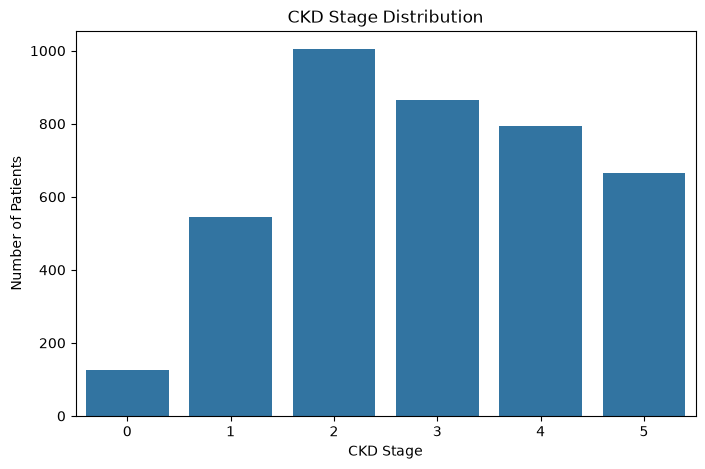

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x="ckd_stage", data=df)
plt.title("CKD Stage Distribution")
plt.xlabel("CKD Stage")
plt.ylabel("Number of Patients")
plt.show()

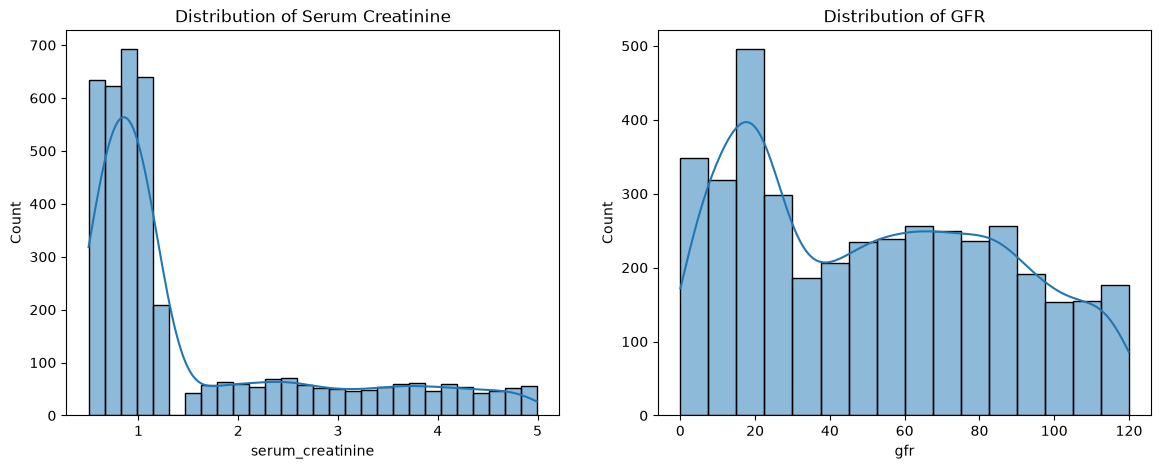

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["serum_creatinine"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Serum Creatinine")
sns.histplot(df["gfr"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of GFR")
plt.show()

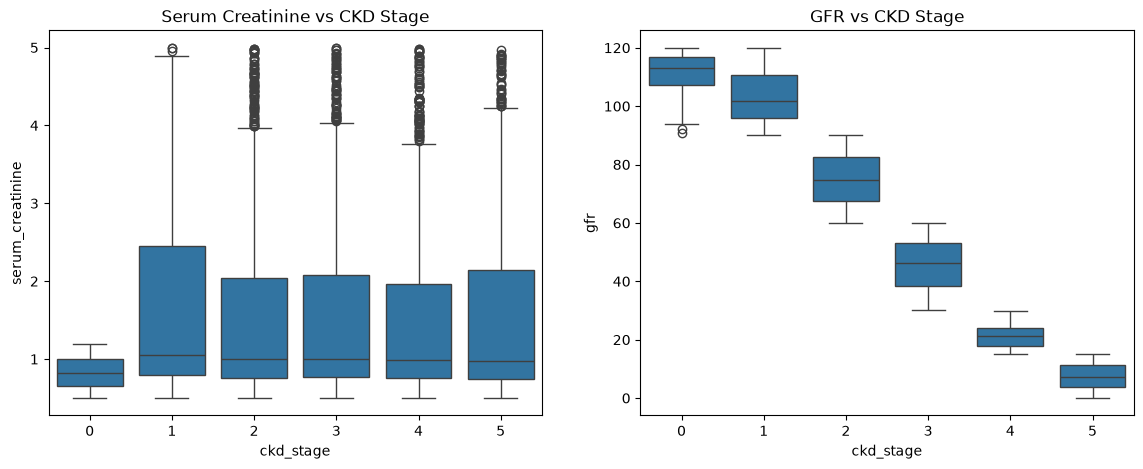

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="ckd_stage", y="serum_creatinine", data=df, ax=axes[0])
axes[0].set_title("Serum Creatinine vs CKD Stage")
sns.boxplot(x="ckd_stage", y="gfr", data=df, ax=axes[1])
axes[1].set_title("GFR vs CKD Stage")
plt.show()

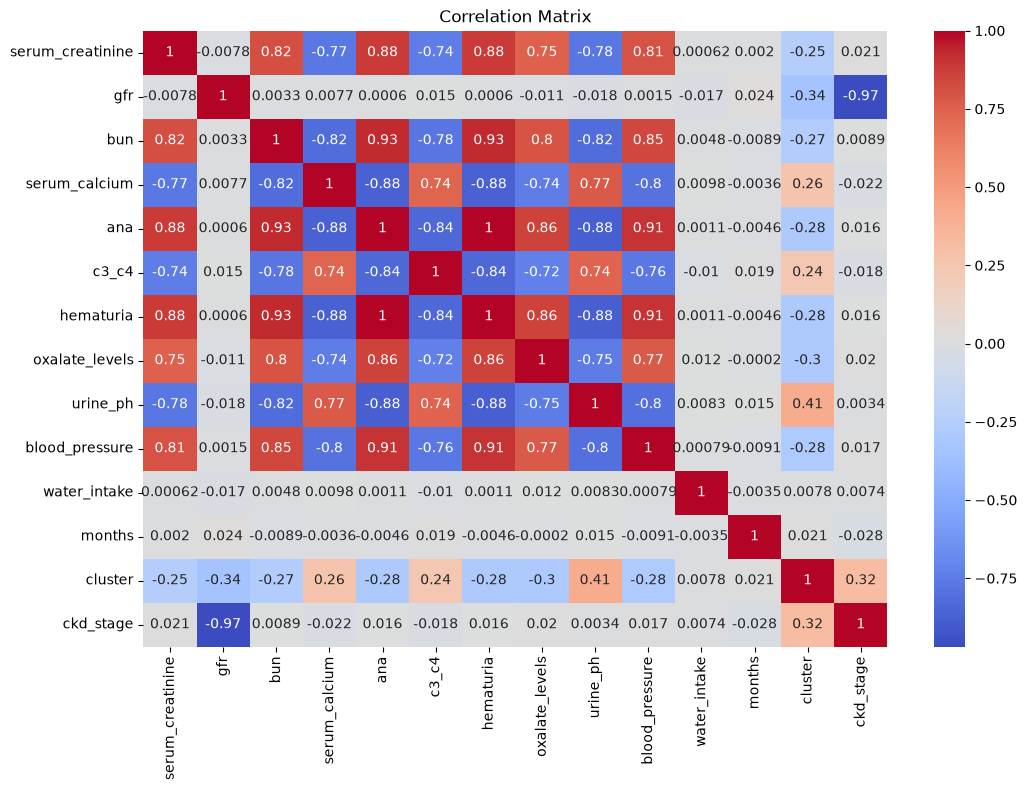

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [14]:
print("GFR range per stage:")
print(df.groupby("ckd_stage")["gfr"].agg(["min", "max", "mean"]).round(1))

print("\nCorrelation of each numeric feature with ckd_stage:")
print(
    df.select_dtypes(include="number")
      .corr()["ckd_stage"].drop("ckd_stage")
      .sort_values(key=abs, ascending=False).round(3)
)

GFR range per stage:
            min    max   mean
ckd_stage                    
0          90.8  119.9  111.3
1          90.0  119.9  103.4
2          60.0   90.0   74.9
3          30.1   60.0   45.8
4          15.0   30.0   21.2
5           0.0   15.0    7.4

Correlation of each numeric feature with ckd_stage:
gfr                -0.968
cluster             0.319
months             -0.028
serum_calcium      -0.022
serum_creatinine    0.021
oxalate_levels      0.020
c3_c4              -0.018
blood_pressure      0.017
ana                 0.016
hematuria           0.016
bun                 0.009
water_intake        0.007
urine_ph            0.003
Name: ckd_stage, dtype: float64


In [15]:
# Reproduce the old setup (no GFR) with a Random Forest to show its ceiling
X_old = pd.get_dummies(df.drop(columns=["ckd_stage", "gfr"] + LEAKY_COLS), drop_first=True)
y_all = df["ckd_stage"].astype(int)

Xtr, Xte, ytr, yte = train_test_split(
    X_old, y_all, test_size=0.20, random_state=SEED, stratify=y_all
)
rf_old = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1).fit(Xtr, ytr)

print("Majority-class baseline accuracy:", round(yte.value_counts(normalize=True).max(), 3))
print("Random Forest WITHOUT gfr, test accuracy:", round(rf_old.score(Xte, yte), 3))

Majority-class baseline accuracy: 0.251
Random Forest WITHOUT gfr, test accuracy: 0.206


In [16]:
feature_cols = [c for c in LAB_FEATURES if INCLUDE_GFR or c != "gfr"]

X = df[feature_cols].copy()
if INCLUDE_LIFESTYLE:
    X = pd.concat([X, pd.get_dummies(df[LIFESTYLE_FEATURES], drop_first=True)], axis=1)

X = X.astype("float32")
y = df["ckd_stage"].astype(int)

print("Number of features:", X.shape[1])
print("Features:", X.columns.tolist())
print("Missing values:", int(X.isnull().sum().sum()))
print("GFR included:", "gfr" in X.columns)

Number of features: 10
Features: ['gfr', 'serum_creatinine', 'bun', 'serum_calcium', 'ana', 'c3_c4', 'hematuria', 'oxalate_levels', 'urine_ph', 'blood_pressure']
Missing values: 0
GFR included: True


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

feature_names = X_train.columns.tolist()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (3200, 10)
Testing data : (800, 10)


Random Forest  train accuracy: 1.0
Random Forest  test  accuracy: 0.9925


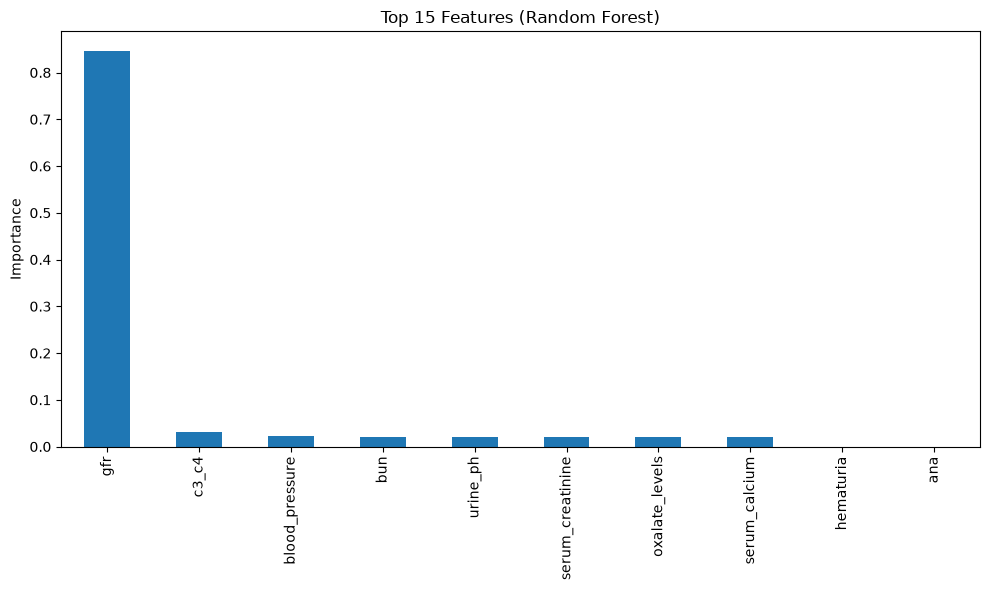

In [18]:
rf = RandomForestClassifier(
    n_estimators=300, random_state=SEED, n_jobs=-1
).fit(X_train, y_train)

print("Random Forest  train accuracy:", round(rf.score(X_train, y_train), 4))
print("Random Forest  test  accuracy:", round(rf.score(X_test, y_test), 4))

feature_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind="bar")
plt.title("Top 15 Features (Random Forest)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [19]:
n_features = X_train.shape[1]

model = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation="relu"),
    Dropout(0.1),

    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(32, activation="relu"),

    Dense(6, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,942 (46.65 KB)

 Trainable params: 11,942 (46.65 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
early_stopping = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1,
)

Epoch 1/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4871 - loss: 1.3294 - val_accuracy: 0.7266 - val_loss: 0.9351 - learning_rate: 0.0010
Epoch 2/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7102 - loss: 0.7647 - val_accuracy: 0.8313 - val_loss: 0.5276 - learning_rate: 0.0010
Epoch 3/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.5153 - val_accuracy: 0.8828 - val_loss: 0.3751 - learning_rate: 0.0010
Epoch 4/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8297 - loss: 0.4128 - val_accuracy: 0.8938 - val_loss: 0.2997 - learning_rate: 0.0010
Epoch 5/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8535 - loss: 0.3515 - val_accuracy: 0.9047 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 6/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8676 - loss: 0.3202 - val_accuracy: 0.9172 - val_loss: 0.2289 - learning_rate: 0.0010
Epoch 7/300
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8773 - loss: 0.2941 - val_acc

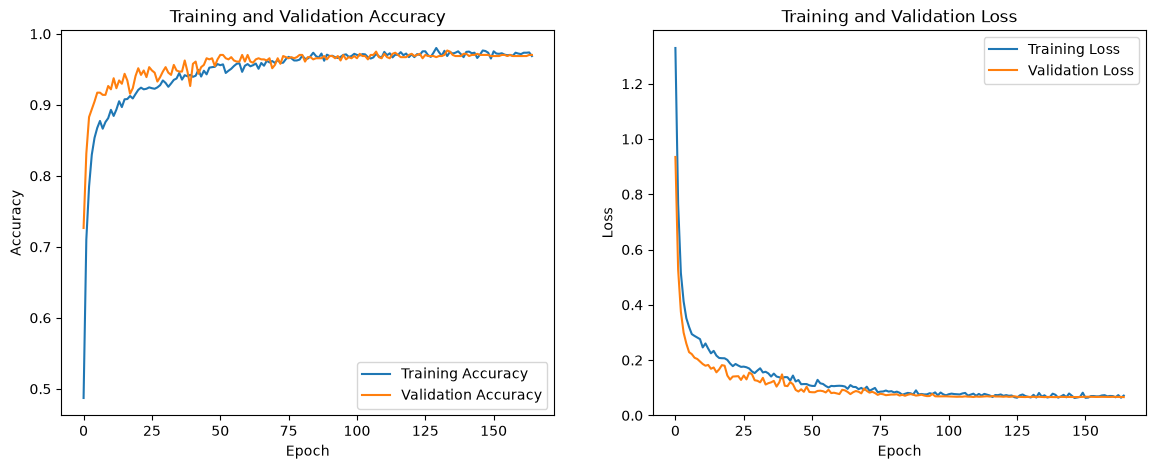

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history.history["loss"], label="Training Loss")
axes[1].plot(history.history["val_loss"], label="Validation Loss")
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.show()

In [22]:
def evaluate(name, X_, y_):
    prob = model.predict(X_, verbose=0)
    pred = np.argmax(prob, axis=1)
    print(f"{name} Accuracy :", round(accuracy_score(y_, pred), 4))
    print(f"{name} Precision:", round(precision_score(y_, pred, average="weighted", zero_division=0), 4))
    print(f"{name} Recall   :", round(recall_score(y_, pred, average="weighted", zero_division=0), 4))
    print(f"{name} F1-Score :", round(f1_score(y_, pred, average="weighted", zero_division=0), 4))
    print()
    return pred

y_train_pred = evaluate("Training", X_train, y_train)
y_test_pred = evaluate("Test    ", X_test, y_test)

Training Accuracy : 0.9897
Training Precision: 0.9896
Training Recall   : 0.9897
Training F1-Score : 0.9896

Test     Accuracy : 0.9663
Test     Precision: 0.9667
Test     Recall   : 0.9663
Test     F1-Score : 0.9663



In [23]:
print("Classification Report (test set):")
print(classification_report(
    y_test, y_test_pred,
    labels=list(range(6)), target_names=STAGE_NAMES, zero_division=0
))

Classification Report (test set):
              precision    recall  f1-score   support

      No CKD       0.96      0.96      0.96        25
     Stage 1       0.98      0.95      0.97       109
     Stage 2       0.97      0.97      0.97       201
     Stage 3       0.95      0.97      0.96       173
     Stage 4       0.95      0.98      0.96       159
     Stage 5       0.99      0.95      0.97       133

    accuracy                           0.97       800
   macro avg       0.97      0.96      0.97       800
weighted avg       0.97      0.97      0.97       800



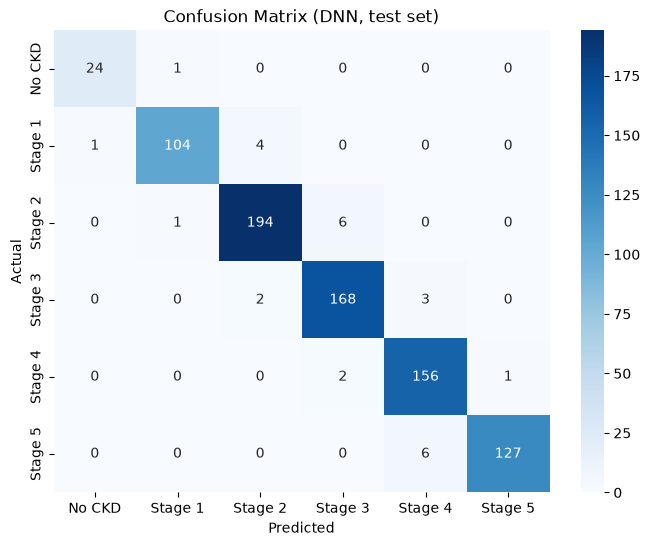

In [24]:
cm = confusion_matrix(y_test, y_test_pred, labels=list(range(6)))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=STAGE_NAMES, yticklabels=STAGE_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (DNN, test set)")
plt.show()

In [25]:
summary = pd.DataFrame({
    "Model": ["Random Forest (no GFR)", "Random Forest", "DNN"],
    "Test accuracy": [
        rf_old.score(Xte, yte),
        rf.score(X_test, y_test),
        accuracy_score(y_test, y_test_pred),
    ],
}).round(4)
summary

,Model,Test accuracy
0,Random Forest (no GFR),0.2062
1,Random Forest,0.9925
2,DNN,0.9662


In [27]:
df[["gfr", "ckd_stage"]].head(20)

,gfr,ckd_stage
0,32.946784,3
1,32.685035,3
2,2.079805,5
3,109.871407,1
4,42.214590,3
5,105.747542,1
6,7.378917,5
7,52.579474,3
8,0.639419,5
9,101.580065,1


In [29]:
# Test the model with a new patient
import pandas as pd
import numpy as np
print("Enter patient details:")

gfr = float(input("GFR: "))
serum_creatinine = float(input("Serum Creatinine: "))
bun = float(input("BUN: "))
serum_calcium = float(input("Serum Calcium: "))
ana = float(input("ANA: "))
c3_c4 = float(input("C3/C4: "))
hematuria = float(input("Hematuria: "))
oxalate_levels = float(input("Oxalate Levels: "))
urine_ph = float(input("Urine pH: "))
blood_pressure = float(input("Blood Pressure: "))

new_patient = pd.DataFrame([[
    gfr,
    serum_creatinine,
    bun,
    serum_calcium,
    ana,
    c3_c4,
    hematuria,
    oxalate_levels,
    urine_ph,
    blood_pressure
]], columns=feature_names)

# Apply the same scaling used during training
new_patient_scaled = scaler.transform(new_patient)

# Predict
prediction_probability = model.predict(new_patient_scaled, verbose=0)
predicted_stage = np.argmax(prediction_probability, axis=1)[0]

print("GFR:", gfr)
print("Serum Creatinine:", serum_creatinine)
print("BUN:", bun)
print("Serum Calcium:", serum_calcium)
print("ANA:", ana)
print("C3/C4:", c3_c4)
print("Hematuria:", hematuria)
print("Oxalate Levels:", oxalate_levels)
print("Urine pH:", urine_ph)
print("Blood Pressure:", blood_pressure)

print("\nPredicted CKD Stage:", STAGE_NAMES[predicted_stage])
print("Confidence:", round(np.max(prediction_probability) * 100, 2), "%")

Enter patient details:
GFR: 45.0
Serum Creatinine: 2.0
BUN: 40.0
Serum Calcium: 8.5
ANA: 0.0
C3/C4: 1.0
Hematuria: 1.0
Oxalate Levels: 35.0
Urine pH: 5.5
Blood Pressure: 140.0

Predicted CKD Stage: Stage 3
Confidence: 100.0 %
